# Adult dataset

## Libraries and notebook setup

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from pgmpy.estimators import BayesianEstimator

from src.effects import (
    DE,
    IE,
    SE,
    TE,
    TV,
    decompose_indirect_effect,
    decompose_spurious_effect,
)
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.preprocess import preprocess_adult_df
from src.visualisation.graph import visualize_sfm
from src.visualisation.sankey import plot_effect_sankey_percent

/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Standard Fairness Model (SFM): single mediator, single confounder

In this section we will work thorugh on presenting the first example of the paper.

Load the dataset, preprocess it, define the SFM on the given attributes. For such SFM we fit a Bayesian Network (BN) using `pgmpy`.

2026-03-10 10:39:29.847 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S1_age': 'N', 'workclass': 'C', 'education': 'C', 'marital-status': 'C', 'occupation': 'C', 'relationship': 'C', 'S3_race': 'C', 'S2_gender': 'C', 'capital-gain': 'N', 'capital-loss': 'N', 'hours-per-week': 'O', 'native-country': 'C', 'T_income': 'C'}


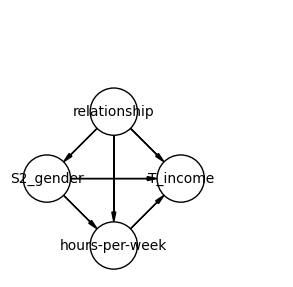

In [5]:
filepath = "./data/processed/adult.csv"
df = pd.read_csv(filepath)
df = preprocess_adult_df(df)

target_attr = "T_income"
private_attr = "S2_gender"
confounders = ["relationship"]
mediators = ["hours-per-week"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=target_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
    sorted_mediators=True,
)

bn = fit_discrete_bayesian_model(
    sfm,
    df,
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()

visualize_sfm(sfm)

Let's compute the effect suite, namely the Total Variation (TV), Total Effect (TE), Experimental Spurious Effect (SE), Natural Direct Effect (DE), Natural Indirect Effect (IE). 

In [6]:
tv = TV(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
total_effect = TE(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
se_male = SE(bn, ("T_income", "<=50K"), "S2_gender", "Male")
se_female = SE(bn, ("T_income", "<=50K"), "S2_gender", "Female")

assert total_effect + (se_female - se_male) == tv

nde_mf = DE(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
nie_fm = IE(
    bn,
    ("T_income", "<=50K"),
    "S2_gender",
    "Female",
    "Male",
)

assert nde_mf - nie_fm == total_effect

print(f"Total Effect: {total_effect:.4f}")
print(f"Spurious Effect (Male): {se_male:.4f}")
print(f"Spurious Effect (Female): {se_female:.4f}")


2026-03-10 10:49:14.229 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-10 10:49:14.232 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-03-10 10:49:14.233 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female


Total Effect: 0.0225
Spurious Effect (Male): -0.0523
Spurious Effect (Female): 0.1191


We can further compute the decompoisitions for the spurious and mediator effects. We expect such decompositions to match the single effects computed above.

In [ ]:
spurious_decomposition_male = decompose_spurious_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Male"
)
spurious_decomposition_female = decompose_spurious_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Female"
)
indirect_decomposition = decompose_indirect_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Female", "Male"
)

We can plot the effects and how they relate within each other in a Sankey Plot.

In [ ]:
plot_effect_sankey_percent(
    target_name="T_income",
    private_name="S2_gender",
    tv=tv,
    te=total_effect,
    se={"Male": se_male, "Female": se_female},
    ie=nie_fm,
    de=nde_mf,
    se_decomp={
        "Male": spurious_decomposition_male,
        "Female": spurious_decomposition_female,
    },
    ie_decomp=indirect_decomposition,
    title="Causal Fairness Decomposition: Hiring Disparity (|TV| = 15%)",
)

In [9]:
tv = TV(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
tot_eff = TE(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
# total_effect_scm(bn, ("T_income", "<=50K"), "S2_gender", x0="Male", x1="Female")

se_male = SE(bn, ("T_income", "<=50K"), "S2_gender", "Male")
se_female = SE(bn, ("T_income", "<=50K"), "S2_gender", "Female")

nde_mf = DE(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
nie_fm = IE(
    bn,
    ("T_income", "<=50K"),
    "S2_gender",
    "Female",
    "Male",
)

print(tot_eff)
print(se_male)
print(se_female)
print(tv)
print(tot_eff + (se_female - se_male))
print(nde_mf, nie_fm)

2026-03-10 09:55:38.907 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-10 09:55:38.909 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-03-10 09:55:38.910 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female


0.022491660596901553
-0.052267965181285736
0.11913998354642641
0.1938996093246137
0.1938996093246137
0.047263336177907345 0.024771675581005792


In [12]:
tot_eff, nde_mf - nie_fm

(np.float64(0.022491660596901553), 0.022491660596901553)

Here we consider more than two states.

In [6]:
# from src.effects import (
#     categorical_natural_direct_effect,
#     categorical_natural_indirect_effect,
#     categorical_total_effect,
#     categorical_total_variation,
# )

# private_states = bn.get_cpds(private_attr).state_names[private_attr]
# protected_states = ["Black"]
# unprotected_states = [s for s in private_states if s not in protected_states]

# res_te = categorical_total_effect(
#     bn,
#     ("T_income", "<=50K"),
#     private_attr,
#     protected_states,
#     unprotected_states,
# )


# res_tv = categorical_total_variation(
#     bn,
#     ("T_income", "<=50K"),
#     private_attr,
#     protected_states,
#     unprotected_states,
# )

# res_nde = categorical_natural_direct_effect(
#     bn, ("T_income", "<=50K"), private_attr, protected_states, unprotected_states
# )

# res_nie = categorical_natural_indirect_effect(
#     bn, ("T_income", "<=50K"), private_attr, protected_states, unprotected_states
# )

If dealing with ordinal variables then simply pass the ordered list for the partitions to both parameters. 

In [7]:
from src.effects import (
    categorical_natural_direct_effect,
    categorical_natural_indirect_effect,
    categorical_total_effect,
    categorical_total_variation,
)

private_states = bn.get_cpds(private_attr).state_names[private_attr]
res_te = categorical_total_effect(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    private_states,
    private_states,
)


res_tv = categorical_total_variation(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    private_states,
    private_states,
)

res_nde = categorical_natural_direct_effect(
    bn, ("T_income", "<=50K"), private_attr, private_states, private_states
)

res_nie = categorical_natural_indirect_effect(
    bn, ("T_income", "<=50K"), private_attr, private_states, private_states
)

2026-03-10 09:48:32.039 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Female, private_mod=Female
2026-03-10 09:48:32.040 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Female, private_mod=Male
2026-03-10 09:48:32.041 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-10 09:48:32.042 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Male


NotImplementedError: This SCM implementation currently assumes exactly one mediator.